# ML Modeler Handover

Notebook này chạy phần ML Modeler từ output của Data Engineer pipeline, train các model, đọc bảng kết quả, chạy diagnostics và gom thông tin cần gửi cho DA.

## 0. Nếu thiếu thư viện

Nếu notebook báo thiếu `pandas`, `sklearn`, `statsmodels` hoặc thư viện tương tự, chạy cell bên dưới một lần rồi restart kernel.

In [1]:
# Chỉ chạy cell này nếu notebook báo ModuleNotFoundError.
# Sau khi cài xong: Kernel -> Restart Kernel, rồi chạy lại từ đầu.
import subprocess
import sys
from pathlib import Path

requirements_path = Path("requirements.txt")
if not requirements_path.exists():
    requirements_path = Path("..") / "requirements.txt"

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-r",
    str(requirements_path),
])


0

## 1. Setup import

Nếu cell check bên dưới báo `sklearn_fallback`, nghĩa là kernel notebook hiện tại chưa import được hàm Part 1. Thường là thiếu `statsmodels` trong đúng Python/Jupyter kernel đang chạy. Khi đó chạy một cell riêng: `%pip install statsmodels`, rồi restart kernel.

In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "part2" / "data" / "melb_data.csv").exists():
    if (ROOT.parent / "part2" / "data" / "melb_data.csv").exists():
        ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
print("Repo root:", ROOT)


Repo root: d:\HieuLT\TUD&TK\datafitting-and-ols-methods


C:\Users\VuiTrinhThiKim\AppData\Local\Temp\ipykernel_13020\2270226131.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
import importlib

from part2.data_pipeline import DataPipeline, load_data, train_test_split
import part2.model_comparison as model_comparison

# Reload so an already-running Jupyter kernel sees the latest local edits.
model_comparison = importlib.reload(model_comparison)

PART1_OLS_FIT = model_comparison.PART1_OLS_FIT
PART1_OLS_IMPORT_ERROR = model_comparison.PART1_OLS_IMPORT_ERROR
PART1_RIDGE_FIT = model_comparison.PART1_RIDGE_FIT
PART1_RIDGE_IMPORT_ERROR = model_comparison.PART1_RIDGE_IMPORT_ERROR
comparison_table = model_comparison.comparison_table
evaluate_gauss_markov_assumptions = model_comparison.evaluate_gauss_markov_assumptions
plot_coefficients = model_comparison.plot_coefficients
plot_predictions = model_comparison.plot_predictions
run_diagnostics = model_comparison.run_diagnostics
train_models = model_comparison.train_models

print("Part 1 OLS available:", PART1_OLS_FIT is not None)
print("Part 1 OLS import error:", PART1_OLS_IMPORT_ERROR)
print("Part 1 Ridge available:", PART1_RIDGE_FIT is not None)
print("Part 1 Ridge import error:", PART1_RIDGE_IMPORT_ERROR)


Part 1 OLS available: True
Part 1 OLS import error: None
Part 1 Ridge available: True
Part 1 Ridge import error: None


## 2. Load data và chạy DE pipeline

Pipeline này tạo `X_train`, `X_test`, `y_train`, `y_test` đã clean, encode, scale. ML không xử lý lại dữ liệu thô.

In [4]:
df = load_data(ROOT / "part2" / "data" / "melb_data.csv")
df_train, df_test = train_test_split(df, test_size=0.3, random_state=42)

# Full feature matrix for initial diagnostics and OLS_baseline.
baseline_pipeline = DataPipeline(drop_columns=[])
X_train_full, y_train = baseline_pipeline.fit_transform(df_train)
X_test_full, y_test = baseline_pipeline.transform(df_test)
metadata_full = {
    "feature_names": list(baseline_pipeline.feature_names),
    "target_name": baseline_pipeline.target_name,
    "drop_columns": list(baseline_pipeline.drop_columns),
    "encoded_columns": list(baseline_pipeline.encoded_columns),
    "numeric_columns": list(baseline_pipeline.imputation_columns),
}

# Selected feature matrix after the current feature-selection gate.
pipeline = DataPipeline(drop_columns=["Bedroom2"])
X_train, y_train = pipeline.fit_transform(df_train)
X_test, y_test = pipeline.transform(df_test)
metadata = {
    "feature_names": list(pipeline.feature_names),
    "target_name": pipeline.target_name,
    "drop_columns": list(pipeline.drop_columns),
    "encoded_columns": list(pipeline.encoded_columns),
    "numeric_columns": list(pipeline.imputation_columns),
}

feature_names_full = metadata_full["feature_names"]
feature_names = metadata["feature_names"]

print("Raw data:", df.shape)
print("X_train_full:", X_train_full.shape, "X_test_full:", X_test_full.shape)
print("X_train_selected:", X_train.shape, "X_test_selected:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)
print("NaNs in X_train_full/X_test_full:", np.isnan(X_train_full).sum(), np.isnan(X_test_full).sum())
print("NaNs in X_train_selected/X_test_selected:", np.isnan(X_train).sum(), np.isnan(X_test).sum())
print("Number of full/selected features:", len(metadata_full["feature_names"]), len(metadata["feature_names"]))


Raw data: (13580, 21)
X_train_full: (9506, 25) X_test_full: (4074, 25)
X_train_selected: (9506, 24) X_test_selected: (4074, 24)
y_train: (9506,) y_test: (4074,)
NaNs in X_train_full/X_test_full: 0 0
NaNs in X_train_selected/X_test_selected: 0 0
Number of full/selected features: 25 24


## 3. Train models

Các model cần train: `OLS`, `Ridge`, `Kernel_Ridge`.

- `OLS`: baseline tuyến tính.
- `Ridge`: tuyến tính có regularization, có tune `alpha` bằng CV.
- `Kernel_Ridge`: baseline phi tuyến, dùng subset để chạy nhanh.

In [5]:
initial_diagnostics = run_diagnostics(
    X_train_full,
    y_train,
    feature_names=metadata_full["feature_names"],
)
display(initial_diagnostics["VIF"].head(15))

baseline_results = train_models(
    X_train_full,
    y_train,
    X_test_full,
    y_test,
    kernel_sample_size=300,
    include_ridge=False,
    include_kernel=False,
    include_bayesian=False,
)

selected_results = train_models(
    X_train,
    y_train,
    X_test,
    y_test,
    kernel_sample_size=300,
)

results = {
    "OLS_baseline": baseline_results["OLS"],
    "OLS_selected": selected_results["OLS"],
    "Ridge_custom": selected_results["Ridge"],
    "Kernel_Ridge": selected_results["Kernel_Ridge"],
    "Bayesian_Linear": selected_results["Bayesian_Linear"],
}

comparison_df = comparison_table(results)
best_lambda = results["Ridge_custom"]["best_lambda"]
cv_scores = results["Ridge_custom"]["cv_scores"]
cv_curve_df = pd.DataFrame({
    "lambda": cv_scores["lambda_values"],
    "mean_cv_rmse": cv_scores["mean_scores"],
    "std_cv_rmse": cv_scores["std_scores"],
})

display(comparison_df)
display(cv_curve_df)
print("Best lambda for Ridge:", best_lambda)
print("Models trained:", list(results.keys()))


,Feature,VIF_Score
0,BuildingArea,36.231201
1,BuildingArea_per_Room,35.926535
2,Rooms,10.503640
3,Bedroom2,8.878682
4,Regionname_Western Metropolitan,6.654466
5,Regionname_Northern Metropolitan,4.843023
6,Regionname_Southern Metropolitan,4.335510
7,Longtitude,4.018864
8,Lattitude,2.638210
9,YearBuilt_missing,2.504087


,Rank,Model,MAE,RMSE,R2,Train_RMSE,Train_R2,Source,Best_Params
0,1,OLS_selected,272055.533485,419817.263759,0.575362,394084.435448,0.617444,part1,{}
1,2,Bayesian_Linear,272055.533469,419817.263759,0.575362,394084.435448,0.617444,advanced_methods,"{'prior_precision': 1e-06, 'noise_precision': ..."
2,3,OLS_baseline,271914.526737,419892.936449,0.575209,393991.460584,0.617624,part1,{}
3,4,Ridge_custom,271172.432146,433807.674984,0.546589,409433.761802,0.587063,part1,"{'alpha': 1000.0, 'lambda': 1000.0, 'cv_rmse':..."
4,5,Kernel_Ridge,295567.130381,499720.825558,0.398338,466077.992924,0.464901,advanced_methods,"{'alpha': 1.0, 'lambda_kernel': 1.0, 'kernel':..."


,lambda,mean_cv_rmse,std_cv_rmse
0,0.001000,6.003841e+05,460868.461056
1,0.003162,6.003707e+05,460838.512314
2,0.010000,6.003284e+05,460743.843360
3,0.031623,6.001947e+05,460444.846159
4,0.100000,5.997736e+05,459503.040916
5,0.316228,5.984583e+05,456561.353595
6,1.000000,5.944555e+05,447609.202059
7,3.162278,5.831745e+05,422377.694732
8,10.000000,5.571086e+05,364067.664763
9,31.622777,5.159696e+05,271954.210688


Best lambda for Ridge: 1000.0
Models trained: ['OLS_baseline', 'OLS_selected', 'Ridge_custom', 'Kernel_Ridge', 'Bayesian_Linear']


## 4. Cách đọc bảng kết quả

- `Rank`: thứ hạng theo `RMSE` thấp nhất.
- `MAE`: sai số tuyệt đối trung bình. Ví dụ MAE = 270000 nghĩa là dự đoán lệch trung bình khoảng 270k AUD.
- `RMSE`: sai số có phạt lỗi lớn mạnh hơn MAE. Đây là metric chính để chọn best model.
- `R2`: phần biến thiên của `Price` được model giải thích. Càng gần 1 càng tốt.
- `Train_RMSE`, `Train_R2`: kết quả trên train, dùng so với test để phát hiện overfit.
- `Source`: model lấy từ Part 1 hay fallback. Kỳ vọng `OLS` và `Ridge` là `part1`.
- `Best_Params`: hyperparameter tốt nhất, đặc biệt `Ridge.alpha` và `cv_rmse`.

In [6]:
best_model_name = comparison_df.iloc[0]["Model"]
best_result = results[best_model_name]
best_predictions = best_result["predictions_test"]
best_residuals = y_test - best_predictions
best_uses_full_matrix = best_model_name == "OLS_baseline"
X_test_for_best = X_test_full if best_uses_full_matrix else X_test
metadata_for_best = metadata_full if best_uses_full_matrix else metadata
feature_names_for_best = metadata_for_best["feature_names"]
best_beta = best_result.get("coefficients")

print("Best model:", best_model_name)
print("Best metrics:", best_result["metrics"])
print("Residual shape:", best_residuals.shape)
print("Prediction NaNs:", np.isnan(best_predictions).sum())
print("Residual NaNs:", np.isnan(best_residuals).sum())


Best model: OLS_selected
Best metrics: {'MAE': 272055.5334853423, 'RMSE': 419817.2637588372, 'R2': 0.575362441761319}
Residual shape: (4074,)
Prediction NaNs: 0
Residual NaNs: 0


## 5. Diagnostics cho DA

DA cần các kết quả này để viết phần Gauss-Markov, residual analysis và multicollinearity.

In [7]:
diagnostics = evaluate_gauss_markov_assumptions(
    X_test_for_best,
    y_test,
    best_residuals,
    feature_names=metadata_for_best["feature_names"],
)

vif_df = diagnostics["VIF"]
display(vif_df.head(15))

print("Breusch-Pagan:", diagnostics["breusch_pagan"])
print("Normality:", diagnostics["normality"])
print("Residual summary:", diagnostics["residual_summary"])


,Feature,VIF_Score
0,Regionname_Western Metropolitan,7.092003
1,BuildingArea,6.137290
2,Rooms,5.439510
3,BuildingArea_per_Room,5.292340
4,Regionname_Northern Metropolitan,4.686348
5,Regionname_Southern Metropolitan,4.328463
6,Longtitude,4.104257
7,Lattitude,2.629006
8,BuildingArea_missing,2.591442
9,YearBuilt_missing,2.462102


Breusch-Pagan: {'lm_statistic': 114.95805248969805, 'p_value': 7.599379069571929e-14, 'df': 24}
Normality: {'test': 'Jarque-Bera', 'statistic': 344646.7169310205, 'p_value': 0.0}
Residual summary: {'mean': 2910.631532892123, 'std': 419858.7060133784, 'min': -2348119.61075014, 'max': 8122695.445482877}


## 6. Coefficients / feature importance

Nếu best model là `OLS` hoặc `Ridge`, coefficients dùng được để DA vẽ feature importance. Nếu best model là `Kernel_Ridge`, model phi tuyến này không có coefficient trực tiếp; khi đó DA nên dùng coefficients của `OLS` hoặc `Ridge` để giải thích.

In [8]:
linear_model_name = best_model_name if results[best_model_name]["coefficients"] is not None else "Ridge_custom"
coefficients = results[linear_model_name]["coefficients"]
linear_metadata = metadata_full if linear_model_name == "OLS_baseline" else metadata
linear_feature_names = linear_metadata["feature_names"]

if coefficients is not None and len(coefficients) == len(linear_metadata["feature_names"]) + 1:
    coefficients_no_intercept = coefficients[1:]
else:
    coefficients_no_intercept = coefficients

coef_df = pd.DataFrame({
    "Feature": linear_metadata["feature_names"],
    "Coefficient": coefficients_no_intercept,
})
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Abs_Coefficient", ascending=False)

print("Coefficient source model:", linear_model_name)
display(coef_df.head(20))


Coefficient source model: OLS_selected


,Feature,Coefficient,Abs_Coefficient
1,Distance,-252703.086059,252703.086059
16,Type_u,-164104.142693,164104.142693
0,Rooms,159809.384231,159809.384231
2,Bathroom,159018.694312,159018.694312
21,Regionname_Southern Metropolitan,112251.797611,112251.797611
15,Type_t,-72664.177450,72664.177450
12,Age,71006.137643,71006.137643
6,Lattitude,-67251.186580,67251.186580
7,Longtitude,61609.781070,61609.781070
11,Landsize_zero_or_missing,-55806.133973,55806.133973


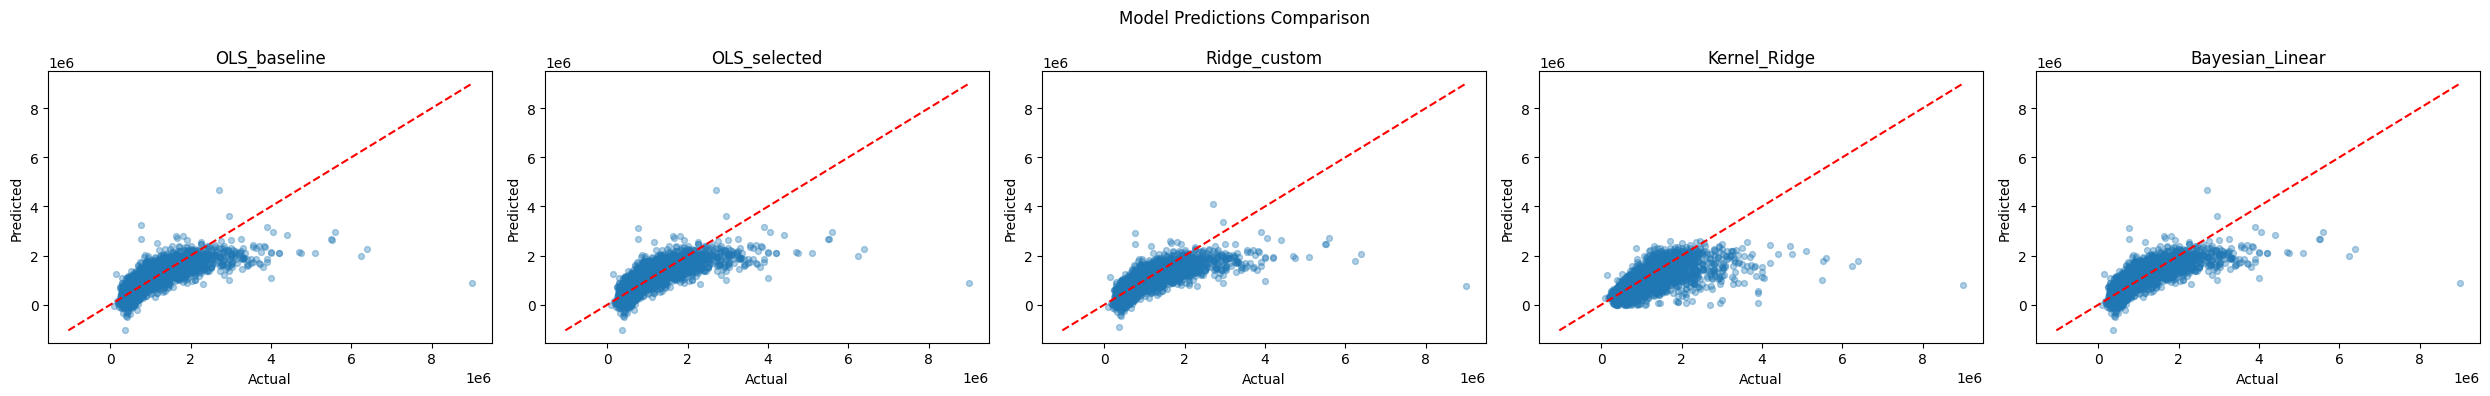

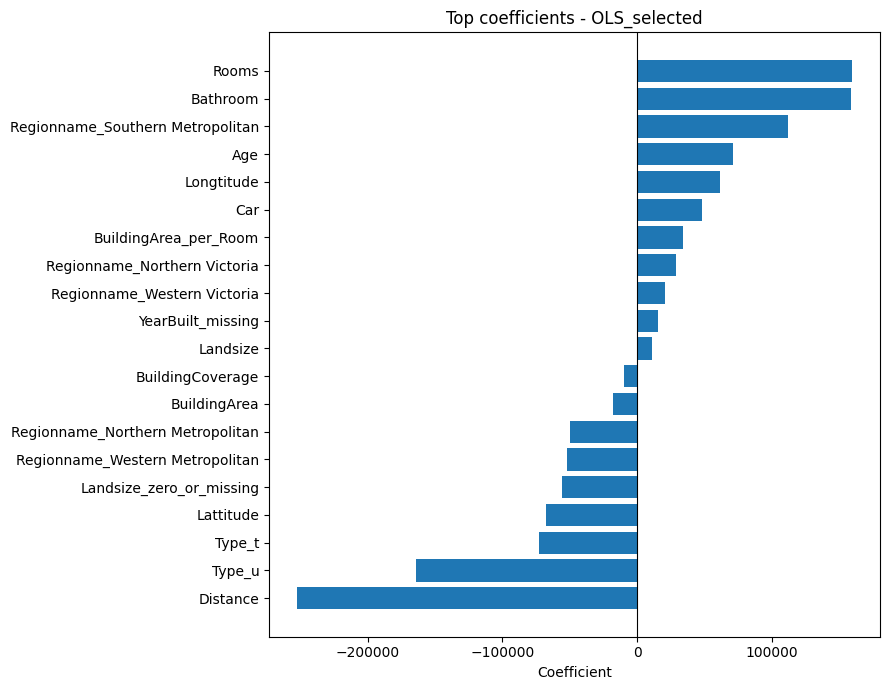

In [9]:
plot_predictions(y_test, results)
plot_coefficients({linear_model_name: results[linear_model_name]}, linear_feature_names, top_n=20);


## 7. Gói bàn giao cho DA

DA cần tối thiểu: bảng so sánh, best model, residuals, VIF, Breusch-Pagan, normality test, coefficients và feature names.

In [10]:
handover_to_da = {
    "results": results,
    "comparison_df": comparison_df,
    "best_model_name": best_model_name,
    "best_metrics": best_result["metrics"],
    "best_beta": best_beta,
    "best_predictions": best_predictions,
    "best_residuals": best_residuals,
    "best_lambda": best_lambda,
    "cv_scores": cv_scores,
    "cv_curve_df": cv_curve_df,
    "gauss_markov_results": diagnostics,
    "initial_diagnostics": initial_diagnostics,
    "linear_coefficients_df": coef_df,
    "metadata": metadata,
    "metadata_full": metadata_full,
    "feature_names": metadata["feature_names"],
    "feature_names_full": metadata_full["feature_names"],
    "ridge_best_params": results["Ridge_custom"]["best_params"],
    "kernel_best_params": results["Kernel_Ridge"].get("best_params"),
    "bayesian_best_params": results["Bayesian_Linear"].get("best_params"),
    "vif_df": vif_df,
    "breusch_pagan": diagnostics["breusch_pagan"],
    "normality_test": diagnostics["normality"],
    "residual_summary": diagnostics["residual_summary"],
}

print("Ready for DA:", handover_to_da.keys())


Ready for DA: dict_keys(['results', 'comparison_df', 'best_model_name', 'best_metrics', 'best_beta', 'best_predictions', 'best_residuals', 'best_lambda', 'cv_scores', 'cv_curve_df', 'gauss_markov_results', 'initial_diagnostics', 'linear_coefficients_df', 'feature_names', 'feature_names_full', 'ridge_best_params', 'vif_df', 'breusch_pagan', 'normality_test', 'residual_summary'])


## 8. Checklist đạt chuẩn

- `comparison_df` có đủ `OLS_baseline`, `OLS_selected`, `Ridge_custom`, `Kernel_Ridge`.
- `OLS_baseline`, `OLS_selected` và `Ridge_custom` nên có `Source = part1`. Nếu là `sklearn_fallback`, kiểm tra cell import Part 1 ở đầu notebook.
- `best_predictions` và `best_residuals` không có NaN.
- `len(best_residuals) == len(y_test)`.
- `vif_df` có cột `Feature`, `VIF_Score`.
- `Ridge_custom` có `best_params` gồm `alpha`, `lambda`, `cv_rmse`; `cv_scores` có dữ liệu vẽ đường cong CV.
- Gửi DA `handover_to_da` hoặc copy từng bảng/biến trong đó.

In [11]:
import json
from pathlib import Path

# ??m b?o th? m?c data t?n t?i
data_dir = ROOT / "part2" / "data"
data_dir.mkdir(parents=True, exist_ok=True)

handover = {
    "best_model_name": best_model_name,
    "best_lambda": float(best_lambda),
    "comparison": comparison_df.to_dict(orient="records"),
    "cv_scores": cv_scores,
    "gauss_markov": {
        "breusch_pagan": diagnostics["breusch_pagan"],
        "normality": diagnostics["normality"],
        "residual_summary": diagnostics["residual_summary"],
    },
    "best_beta": best_beta.tolist() if best_beta is not None else None,
    "best_residuals": best_residuals.tolist(),
    "feature_names": metadata_for_best["feature_names"],
    "metadata": metadata,
    "metadata_full": metadata_full,
    "ridge_best_params": results["Ridge_custom"]["best_params"],
    "kernel_best_params": results["Kernel_Ridge"].get("best_params"),
    "bayesian_best_params": results["Bayesian_Linear"].get("best_params"),
    "initial_vif_top15": initial_diagnostics["VIF"].head(15).to_dict(orient="records"),
    "vif_top15": diagnostics["VIF"].head(15).to_dict(orient="records"),
    "sources": {
        "data_pipeline": "part2/data_pipeline.py",
        "model_comparison": "part2/model_comparison.py",
        "advanced_methods": "part2/advanced_methods.py",
    },
}

# S? d?ng Path ?? l?u file ch?nh x?c
output_path = data_dir / "handover_b_to_c.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(handover, f, ensure_ascii=False, indent=2)

print(f"Saved handover file to: {output_path}")


Saved handover file to: d:\HieuLT\TUD&TK\datafitting-and-ols-methods\part2\data\handover_b_to_c.json
